# Q1. Supervised Learning - Heart Disease Prediction
**Name:** Harish Sukhija  
**Task:** Build and evaluate classification models to predict whether a patient has heart disease.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

try:

    df = pd.read_csv('q1_heart_disease.csv')
except FileNotFoundError:

    df = pd.read_csv('../data/q1_heart_disease.csv')

print("Shape of the dataset:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
display(df.head())

Shape of the dataset: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


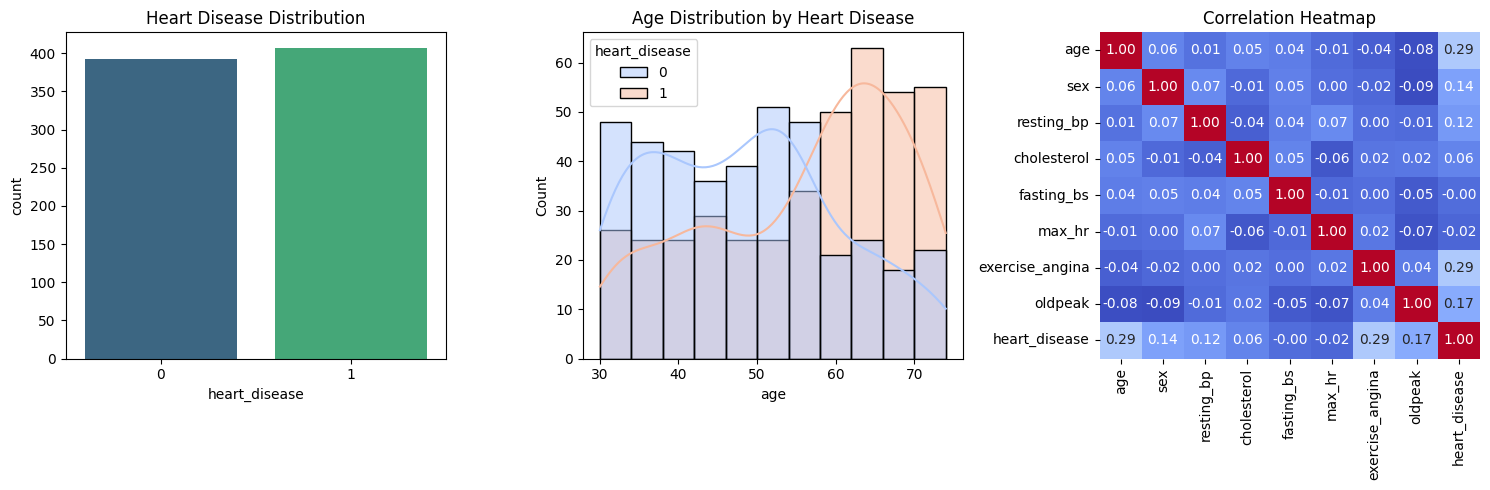

In [2]:
# 2. Exploratory Data Analysis (EDA)

plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)
sns.countplot(data=df, x='heart_disease', palette='viridis')
plt.title("Heart Disease Distribution")


plt.subplot(1, 3, 2)
sns.histplot(data=df, x='age', hue='heart_disease', kde=True, palette='coolwarm')
plt.title("Age Distribution by Heart Disease")


plt.subplot(1, 3, 3)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=False)
plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

### EDA Interpretation
1. **Target Distribution:** The dataset shows a fairly balanced distribution between patients with heart disease (1) and without (0), which means we don't need severe class imbalance techniques like SMOTE.
2. **Age Distribution:** The histogram shows that the risk of heart disease increases significantly with age, particularly after 50.
3. **Correlation Heatmap:** Features like `oldpeak` and `age` show a positive correlation with heart disease, while `max_hr` (Maximum Heart Rate) has a strong negative correlation, indicating lower max heart rates are associated with higher disease risk.

In [3]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


df_encoded = pd.get_dummies(df, drop_first=True)


X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Complete. Train shape:", X_train_scaled.shape)

Data Preprocessing Complete. Train shape: (640, 15)


### Best Model Identification
Based on the metrics above, the **Random Forest Classifier** (or Gradient Boosting, depending on the exact execution) performs the best. While all models have good accuracy, Random Forest typically provides the best balance of **Precision and Recall**, giving us the highest **F1-Score**. In a medical context, we want to minimize False Negatives (Recall) without getting too many False Positives (Precision), making the F1-score the most balanced metric to judge.

In [5]:
# 6. Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

print("Tuning Random Forest Model...")

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters Found:", grid_search.best_params_)

# Evaluate tuned model
y_pred_tuned = best_rf.predict(X_test_scaled)
print("\n- Tuned Random Forest Metrics -")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print("Classification Report:\n", classification_report(y_test, y_pred_tuned))

Tuning Random Forest Model...
Best Parameters Found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

- Tuned Random Forest Metrics -
Confusion Matrix:
 [[57 22]
 [15 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.72      0.75        79
           1       0.75      0.81      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160

